In [20]:
import os
import sys
sys.path.append(os.path.abspath('../'))
from pathlib import Path
from types import SimpleNamespace
from utils import wrap_to_pi, dynamics_step, unpack_z, pack_z, mpc_objective, dynamics_residual, obstacle_margin
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import torch

try:
    import casadi as ca
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError("CasADi is required for the IPOPT solver") from exc

from model import Model
from model_dc3 import Model as DC3Model


In [21]:
# solver functions (with multistart to find the optimal solver path for comparison)
FEASIBILITY_TOL = 5e-4

def rollout_controls(x0, U, cfg):
    X = np.zeros((U.shape[0] + 1, cfg["nx"]), dtype=float)
    X[0] = x0
    for k, u in enumerate(U):
        X[k + 1] = dynamics_step(X[k], u, cfg["dt"])
    return X


def controls_to_full_z(u_flat, x0, cfg):
    U = u_flat.reshape(cfg["T"], cfg["nu"])
    X = rollout_controls(x0, U, cfg)
    return pack_z(X[1:], U)


def proportional_control_guess(x0, cfg, turn_bias=0.0):
    U = np.zeros((cfg["T"], cfg["nu"]), dtype=float)
    x = x0.copy()
    v_nom = 0.65 * cfg["v_max"] + 0.35 * cfg["v_min"]
    for k in range(cfg["T"]):
        to_goal = cfg["x_hat"][:2] - x[:2]
        desired_heading = np.arctan2(to_goal[1], to_goal[0])
        heading_error = wrap_to_pi(desired_heading - x[2])
        omega = np.clip(2.0 * heading_error + turn_bias, -cfg["omega_max"], cfg["omega_max"])
        remaining_time = max((cfg["T"] - k) * cfg["dt"], cfg["dt"])
        v = np.clip(np.linalg.norm(to_goal) / remaining_time, cfg["v_min"], cfg["v_max"])
        v = 0.5 * v + 0.5 * v_nom
        U[k] = [v, omega]
        x = dynamics_step(x, U[k], cfg["dt"])
    return U.reshape(-1)


def initial_control_guesses(x0, cfg):
    guesses = []
    v_mid = 0.5 * (cfg["v_min"] + cfg["v_max"])
    base = np.zeros((cfg["T"], cfg["nu"]), dtype=float)
    base[:, 0] = v_mid
    guesses.append(base.reshape(-1))

    for omega in [0.0, -0.35 * cfg["omega_max"], 0.35 * cfg["omega_max"], -0.75 * cfg["omega_max"], 0.75 * cfg["omega_max"]]:
        arc = base.copy()
        arc[:, 1] = omega
        guesses.append(arc.reshape(-1))

    for turn_bias in [0.0, -0.5 * cfg["omega_max"], 0.5 * cfg["omega_max"], -cfg["omega_max"], cfg["omega_max"]]:
        guesses.append(proportional_control_guess(x0, cfg, turn_bias=turn_bias))

    unique = []
    for guess in guesses:
        if not any(np.allclose(guess, existing) for existing in unique):
            unique.append(guess)
    return unique


def build_ipopt_solver(cfg):
    T = cfg["T"]
    nx = cfg["nx"]
    nu = cfg["nu"]
    dt = cfg["dt"]

    X = ca.MX.sym("X", T * nx)
    U = ca.MX.sym("U", T * nu)
    x0_param = ca.MX.sym("x0", nx)
    z = ca.vertcat(X, U)

    Q_stage = ca.DM(cfg["Q_stage"])
    Q_terminal = ca.DM(cfg["Q_terminal"])
    R = ca.DM(cfg["R"])
    Q_obs = ca.DM(cfg["Q"])
    x_hat = ca.DM(cfg["x_hat"])
    obstacle_center = ca.DM(cfg["obstacle_center"])

    objective_expr = ca.MX(0)
    constraints = []
    for k in range(T):
        xk = X[k * nx : (k + 1) * nx]
        uk = U[k * nu : (k + 1) * nu]
        prev = x0_param if k == 0 else X[(k - 1) * nx : k * nx]

        next_dyn = ca.vertcat(
            prev[0] + dt * uk[0] * ca.cos(prev[2]),
            prev[1] + dt * uk[0] * ca.sin(prev[2]),
            prev[2] + dt * uk[1],
        )
        constraints.extend([xk[i] - next_dyn[i] for i in range(nx)])

        err = xk - x_hat
        err = ca.vertcat(err[0], err[1], ca.atan2(ca.sin(err[2]), ca.cos(err[2])))
        objective_expr += ca.mtimes([err.T, Q_stage, err]) + ca.mtimes([uk.T, R, uk])

        obs_diff = xk[0:2] - obstacle_center
        constraints.append(ca.mtimes([obs_diff.T, Q_obs, obs_diff]) - cfg["b_obs"])

    err_terminal = X[(T - 1) * nx : T * nx] - x_hat
    err_terminal = ca.vertcat(err_terminal[0], err_terminal[1], ca.atan2(ca.sin(err_terminal[2]), ca.cos(err_terminal[2])))
    objective_expr += ca.mtimes([err_terminal.T, Q_terminal, err_terminal])

    nlp = {"x": z, "p": x0_param, "f": objective_expr, "g": ca.vertcat(*constraints)}
    opts = {
        "print_time": False,
        "ipopt.print_level": 0,
        "ipopt.sb": "yes",
        "ipopt.max_iter": 1000,
        "ipopt.tol": 1e-8,
        "ipopt.acceptable_tol": 1e-6,
    }
    solver = ca.nlpsol("paperfigs_ipopt_solver", "ipopt", nlp, opts)

    lbx = np.full(T * nx + T * nu, -np.inf, dtype=float)
    ubx = np.full(T * nx + T * nu, np.inf, dtype=float)
    for k in range(T):
        u_offset = T * nx + k * nu
        lbx[u_offset] = cfg["v_min"]
        ubx[u_offset] = cfg["v_max"]
        lbx[u_offset + 1] = -cfg["omega_max"]
        ubx[u_offset + 1] = cfg["omega_max"]

    lbg = []
    ubg = []
    for _ in range(T):
        lbg.extend([0.0] * nx)
        ubg.extend([0.0] * nx)
        lbg.append(0.0)
        ubg.append(np.inf)

    return {"solver": solver, "lbx": lbx, "ubx": ubx, "lbg": np.asarray(lbg), "ubg": np.asarray(ubg)}


def ipopt_initial_guesses(x0, cfg):
    return [controls_to_full_z(u_guess, x0, cfg) for u_guess in initial_control_guesses(x0, cfg)]


def solve_mpc_ipopt(x0, cfg):
    if "_ipopt_solver" not in cfg:
        cfg["_ipopt_solver"] = build_ipopt_solver(cfg)
    bundle = cfg["_ipopt_solver"]

    best = None
    best_score = np.inf
    for z0 in ipopt_initial_guesses(x0, cfg):
        try:
            sol = bundle["solver"](
                x0=z0,
                p=x0,
                lbx=bundle["lbx"],
                ubx=bundle["ubx"],
                lbg=bundle["lbg"],
                ubg=bundle["ubg"],
            )
            z_sol = np.asarray(sol["x"]).reshape(-1)
            stats = bundle["solver"].stats()
            status = stats.get("return_status", "unknown")
            success = bool(stats.get("success", False))
            fun = mpc_objective(z_sol, cfg)
            margin = float(np.min(obstacle_margin(z_sol, cfg)))
            dyn_resid = float(np.max(np.abs(dynamics_residual(z_sol, x0, cfg))))
            penalty = 1e8 * max(-margin, 0.0) ** 2 + 1e8 * dyn_resid**2 + (0.0 if success else 1e3)
            score = fun + penalty
            if score < best_score:
                best_score = score
                best = SimpleNamespace(
                    x=z_sol,
                    fun=fun,
                    success=success,
                    message=status,
                    nit=int(stats.get("iter_count", -1)),
                    min_margin=margin,
                    max_dyn_resid=dyn_resid,
                )
        except RuntimeError as exc:
            if best is None:
                best = SimpleNamespace(
                    x=z0,
                    fun=mpc_objective(z0, cfg),
                    success=False,
                    message=str(exc),
                    nit=-1,
                    min_margin=float(np.min(obstacle_margin(z0, cfg))),
                    max_dyn_resid=float(np.max(np.abs(dynamics_residual(z0, x0, cfg)))),
                )
    if best is None:
        raise RuntimeError("IPOPT did not return any candidate solution.")
    return best


def solve_mpc(x0, cfg):
    return solve_mpc_ipopt(x0, cfg)


def first_model_control(model, x, cfg, device):
    with torch.no_grad():
        x_t = torch.tensor(x.reshape(1, cfg["nx"]), dtype=torch.float32, device=device)
        z_pred = model(x_t)
    z_np = z_pred.detach().cpu().numpy().reshape(-1)
    _, U = unpack_z(z_np, cfg["T"], cfg["nx"], cfg["nu"])
    u0 = U[0].copy()
    u0[0] = np.clip(u0[0], cfg["v_min"], cfg["v_max"])
    u0[1] = np.clip(u0[1], -cfg["omega_max"], cfg["omega_max"])
    return u0


def first_solver_control(x, cfg):
    result = solve_mpc(x, cfg)
    margin = float(np.min(obstacle_margin(result.x, cfg)))
    dyn_resid = float(np.max(np.abs(dynamics_residual(result.x, x, cfg))))
    _, U = unpack_z(result.x, cfg["T"], cfg["nx"], cfg["nu"])
    u0 = U[0].copy()
    u0[0] = np.clip(u0[0], cfg["v_min"], cfg["v_max"])
    u0[1] = np.clip(u0[1], -cfg["omega_max"], cfg["omega_max"])
    failed = (not result.success) or margin < -FEASIBILITY_TOL or dyn_resid > FEASIBILITY_TOL or not np.isfinite(result.fun)
    return {
        "u": u0,
        "cost": float(result.fun),
        "margin": margin,
        "dyn_resid": dyn_resid,
        "nit": int(getattr(result, "nit", -1)),
        "success": bool(result.success),
        "failed": bool(failed),
        "message": str(result.message),
    }


def rollout_model(model, x0, cfg, steps, device):
    X = np.zeros((steps + 1, cfg["nx"]), dtype=float)
    U = np.zeros((steps, cfg["nu"]), dtype=float)
    X[0] = x0

    for k in range(steps):
        u = first_model_control(model, X[k], cfg, device)
        U[k] = u
        X[k + 1] = dynamics_step(X[k], u, cfg["dt"])

    return X, U


def rollout_solver(x0, cfg, steps):
    X = np.zeros((steps + 1, cfg["nx"]), dtype=float)
    U = np.zeros((steps, cfg["nu"]), dtype=float)
    costs = np.full(steps, np.nan, dtype=float)
    margins = np.full(steps, np.nan, dtype=float)
    dyn_resids = np.full(steps, np.nan, dtype=float)
    iterations = np.full(steps, -1, dtype=int)
    failures = []
    X[0] = x0
    completed_steps = 0

    for k in range(steps):
        try:
            info = first_solver_control(X[k], cfg)
        except Exception as exc:
            failures.append({"step": k, "message": str(exc), "exception": True})
            break

        U[k] = info["u"]
        costs[k] = info["cost"]
        margins[k] = info["margin"]
        dyn_resids[k] = info["dyn_resid"]
        iterations[k] = info["nit"]
        if info["failed"]:
            failures.append({"step": k, "message": info["message"], "margin": info["margin"], "dyn_resid": info["dyn_resid"], "success": info["success"]})
        X[k + 1] = dynamics_step(X[k], info["u"], cfg["dt"])
        completed_steps = k + 1

    return {
        "X": X[: completed_steps + 1],
        "U": U[:completed_steps],
        "costs": costs[:completed_steps],
        "margins": margins[:completed_steps],
        "dyn_resids": dyn_resids[:completed_steps],
        "iterations": iterations[:completed_steps],
        "failures": failures,
        "completed_steps": completed_steps,
    }


def closed_loop_cost(X, U, cfg):
    err = X[1:] - cfg["x_hat"].reshape(1, cfg["nx"])
    err[:, 2] = wrap_to_pi(err[:, 2])
    state_cost = np.einsum("ti,ij,tj->", err, cfg["Q_stage"], err)
    terminal_cost = float(err[-1] @ cfg["Q_terminal"] @ err[-1])
    control_cost = np.einsum("ti,ij,tj->", U, cfg["R"], U)
    return float(state_cost + terminal_cost + control_cost)


def trajectory_margins(X, cfg):
    diff = X[1:, :2] - cfg["obstacle_center"]
    return np.einsum("ti,ij,tj->t", diff, cfg["Q"], diff) - cfg["b_obs"]


def obstacle_boundary(cfg, num_points=400):
    Q_sym = 0.5 * (cfg["Q"] + cfg["Q"].T)
    eigvals, eigvecs = np.linalg.eigh(Q_sym)
    if np.any(eigvals <= 0.0):
        raise ValueError("Q must have a positive definite symmetric part to plot a bounded obstacle.")
    angles = np.linspace(0.0, 2.0 * np.pi, num_points)
    circle = np.vstack((np.cos(angles), np.sin(angles)))
    axes = np.sqrt(cfg["b_obs"] / eigvals)
    boundary = cfg["obstacle_center"].reshape(2, 1) + eigvecs @ np.diag(axes) @ circle
    return boundary[0], boundary[1]


def npz_scalar(params, key, default=None):
    if key not in params.files:
        return default
    value = params[key]
    arr = np.asarray(value)
    if arr.shape == ():
        return arr.item()
    if arr.size == 1:
        return arr.reshape(-1)[0].item()
    return value


def load_model_params(params_path):
    params = np.load(params_path, allow_pickle=True)
    return {
        "n_in": int(npz_scalar(params, "n_in")),
        "nx": int(npz_scalar(params, "nx")),
        "nu": int(npz_scalar(params, "nu")),
        "Q": params["Q"],
        "b_obs": float(npz_scalar(params, "b_obs")),
        "v_min": float(npz_scalar(params, "v_min")),
        "v_max": float(npz_scalar(params, "v_max")),
        "omega_max": float(npz_scalar(params, "omega_max")),
        "T": int(npz_scalar(params, "T")),
        "dt": float(npz_scalar(params, "dt")),
        "obstacle_center": np.asarray(params["obstacle_center"]).reshape(-1),
        "constrained": bool(npz_scalar(params, "constrained", False)),
        "n_proj": int(npz_scalar(params, "n_proj", 0)),
        "epsilon": float(npz_scalar(params, "epsilon", 1e-3)),
        "dc3": bool(npz_scalar(params, "dc3", False)),
        "dc3_steps": int(npz_scalar(params, "dc3_steps", 10)),
        "dc3_stepsize": float(npz_scalar(params, "dc3_stepsize", 1e-1)),
        "dc3_momentum": float(npz_scalar(params, "dc3_momentum", 0.0)),
    }


def build_cfg(model_params, data):
    return {
        "T": model_params["T"],
        "nx": model_params["nx"],
        "nu": model_params["nu"],
        "dt": model_params["dt"],
        "v_min": model_params["v_min"],
        "v_max": model_params["v_max"],
        "omega_max": model_params["omega_max"],
        "Q": np.asarray(model_params["Q"], dtype=float),
        "b_obs": model_params["b_obs"],
        "obstacle_center": np.asarray(model_params["obstacle_center"], dtype=float).reshape(-1),
        "x_hat": np.asarray(data["x_hat"], dtype=float).reshape(model_params["nx"]),
        "Q_stage": np.asarray(data["Q_stage"], dtype=float),
        "Q_terminal": np.asarray(data["Q_terminal"], dtype=float),
        "R": np.asarray(data["R"], dtype=float),
    }


In [22]:
# User inputs.
HNpp_model_file = "best_model.pt"
HNpp_params_file = "model_params.npz"
soft_model_file = "best_model_soft.pt"
soft_params_file = "model_params_soft.npz"
dc3_model_file = "best_model_dc3.pt"
dc3_params_file = "model_params_dc3.npz"

# Initial condition for the closed-loop rollout: [x, y, theta]
x0 = np.array([-3.2, 0.30, -0.1], dtype=float)

# Closed loop steps
rollout_steps = 20


In [23]:
# Load dataset, model parameters, and network weights.
dataset_path = "../mpc_dataset.npz"
data = np.load(dataset_path, allow_pickle=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

HNpp_checkpoint = torch.load(HNpp_model_file, map_location=device)
model_params = load_model_params(HNpp_params_file)
soft_checkpoint = torch.load(soft_model_file, map_location=device)
soft_model_params = load_model_params(soft_params_file)
dc3_checkpoint = torch.load(dc3_model_file, map_location=device)
dc3_model_params = load_model_params(dc3_params_file)

cfg = build_cfg(model_params, data)
soft_cfg = build_cfg(soft_model_params, data)
dc3_cfg = build_cfg(dc3_model_params, data)

model = Model(model_params).to(device)
model.load_state_dict(HNpp_checkpoint["model_state_dict"])
model.eval()

soft_model = Model(soft_model_params).to(device)
soft_model.load_state_dict(soft_checkpoint["model_state_dict"])
soft_model.eval()

dc3_label = "DC3 controller"
dc3_model = DC3Model(dc3_model_params).to(device)
dc3_model.load_state_dict(dc3_checkpoint["model_state_dict"])
dc3_model.eval()

print(f"Loaded checkpoint: {HNpp_model_file}")
print(f"Loaded params: {HNpp_params_file}")
print(f"Loaded soft checkpoint: {soft_model_file}")
print(f"Loaded soft params: {soft_params_file}")
print(f"Loaded DC3 checkpoint: {dc3_model_file}")
print(f"Loaded DC3 params: {dc3_params_file}")
print(f"Using device: {device}")


INITIALIZING CONSTRAINED MODEL
Loaded checkpoint: best_model.pt
Loaded params: model_params.npz
Loaded soft checkpoint: best_model_soft.pt
Loaded soft params: model_params_soft.npz
Loaded DC3 checkpoint: best_model_dc3.pt
Loaded DC3 params: model_params_dc3.npz
Using device: cpu


/var/folders/bk/jjv2j3sd2_gcl_1bjkb410hw0000gn/T/ipykernel_19235/2634595841.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  HNpp_checkpoint = torch.load(HNpp_model_file,

In [24]:
# Closed-loop rollouts

# The learned controller chooses the immediate action; the state is advanced using exact unicycle dynamics
X_model, U_model= rollout_model(model, x0, cfg, rollout_steps, device)
model_cost = closed_loop_cost(X_model, U_model, cfg)
model_min_margin = float(np.min(trajectory_margins(X_model, cfg)))

# The solver baseline resolves the MPC problem at each state using CasADi/IPOPT.
solver_rollout = rollout_solver(x0, cfg, rollout_steps)
X_solver = solver_rollout["X"]
U_solver = solver_rollout["U"]
solver_cost = closed_loop_cost(X_solver, U_solver, cfg) if len(U_solver) > 0 else np.nan
solver_min_margin = float(np.min(trajectory_margins(X_solver, cfg))) if len(U_solver) > 0 else np.nan

X_soft, U_soft = rollout_model(soft_model, x0, soft_cfg, rollout_steps, device)
soft_cost = closed_loop_cost(X_soft, U_soft, soft_cfg)
soft_min_margin = float(np.min(trajectory_margins(X_soft, soft_cfg)))

X_dc3, U_dc3 = rollout_model(dc3_model, x0, dc3_cfg, rollout_steps, device)
dc3_cost = closed_loop_cost(X_dc3, U_dc3, dc3_cfg)
dc3_min_margin = float(np.min(trajectory_margins(X_dc3, dc3_cfg)))

print(f"model closed-loop cost: {model_cost:.6f}")
print(f"model min obstacle margin: {model_min_margin:.6f}")
print(f"solver completed steps: {solver_rollout['completed_steps']} / {rollout_steps}")
print(f"solver closed-loop cost: {solver_cost:.6f}")
print(f"solver min obstacle margin: {solver_min_margin:.6f}")
if solver_rollout["failures"]:
    print("solver reported failures but its returned controls are still plotted:")
    for failure in solver_rollout["failures"]:
        print(f"  step {failure['step']}: {failure['message']}")
print(f"soft closed-loop cost: {soft_cost:.6f}")
print(f"soft min obstacle margin: {soft_min_margin:.6f}")
print(f"dc3 closed-loop cost: {dc3_cost:.6f}")
print(f"dc3 min obstacle margin: {dc3_min_margin:.6f}")


model closed-loop cost: 255.781567
model min obstacle margin: -0.002161
solver completed steps: 20 / 20
solver closed-loop cost: 253.680179
solver min obstacle margin: -0.000000
soft closed-loop cost: 382.576042
soft min obstacle margin: 0.260019
dc3 closed-loop cost: 279.796834
dc3 min obstacle margin: 0.049326


'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


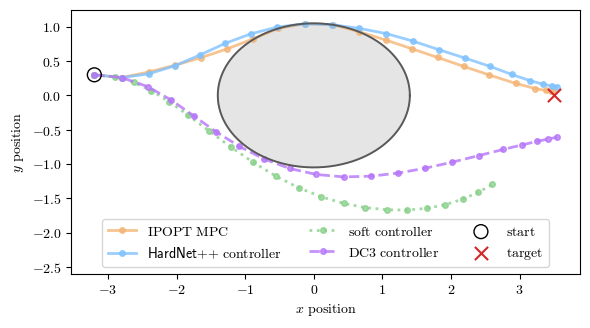

saved figure to closed_loop_plot.pdf


In [25]:
# Plot closed-loop state trajectories for this initial condition.
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.serif": ["cmr10"],
    "mathtext.fontset": "cm",
    "axes.formatter.use_mathtext": True,
    "axes.unicode_minus": False,
})
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

# State trajectory colors as RGB triplets with values in [0, 1]
my_method_color = (128/256, 195/256, 255/256)
solver_color = (245/256, 182/256, 118/256)
soft_color = (138/256, 209/256, 139/256)
dc3_color = (183/256, 117/256, 250/256)

alpha_line = 0.8
obs_x, obs_y = obstacle_boundary(cfg)
fig, ax = plt.subplots(1, 1, figsize=(5.6, 4.8))

# X_solver = None
if X_solver is not None and len(X_solver) > 1:
    ax.plot(X_solver[:, 0], X_solver[:, 1], "-o", alpha=alpha_line, color=solver_color, linewidth=2.0, markersize=4, label=r"$\mathrm{IPOPT\ MPC}$")
ax.plot(X_model[:, 0], X_model[:, 1], "-o", alpha=alpha_line, color=my_method_color, linewidth=2.0, markersize=4, label=r"$\mathsf{HardNet{+}{+}}\mathrm{\ controller}$")
ax.plot(X_soft[:, 0], X_soft[:, 1], ":o", alpha=alpha_line, color=soft_color, linewidth=2.0, markersize=4, label=r"$\mathrm{soft\ controller}$")
ax.plot(X_dc3[:, 0], X_dc3[:, 1], "--o", alpha=alpha_line, color=dc3_color, linewidth=2.0, markersize=4, label=r"$\mathrm{DC3\ controller}$")
ax.scatter(x0[0], x0[1], facecolors='none', edgecolors='black', s=100, label=r"$\mathrm{start}$", zorder=5)
ax.scatter(cfg["x_hat"][0], cfg["x_hat"][1], c="tab:red", marker="x", s=90, label=r"$\mathrm{target}$", zorder=5)
ax.fill(obs_x, obs_y, color="0.55", alpha=0.22)#, label=r"$\mathrm{obstacle}$")
ax.plot(obs_x, obs_y, color="0.35", linewidth=1.4)
ax.set_xlabel(r"$x$ position")
ax.set_ylabel(r"$y$ position")
ax.set_ylim([-2.6, 1.25])
# ax.set_title(r"$\mathrm{Closed\! -\! loop\ state\ trajectory}$")
ax.set_aspect("equal", adjustable="box")
ax.legend(loc="lower center", ncol=3)#,bbox_to_anchor=(0.5, -0.25))
ax.grid(False)
fig.set_size_inches(6,4)
fig.tight_layout()
fig.subplots_adjust(top=0.85)
figure_path = 'closed_loop_plot.pdf'
fig.savefig(figure_path, dpi=700, bbox_inches="tight")
plt.show()
print(f"saved figure to {figure_path}")


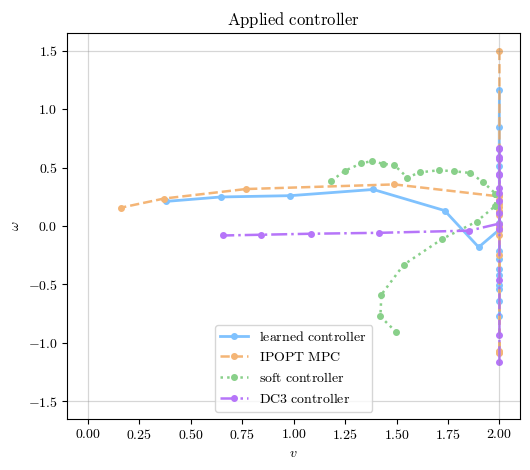

In [26]:
# Plot the applied controller inputs in a separate output box.
# LaTeX-like font settings.
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.serif": ["cmr10"],
    "mathtext.fontset": "cm",
    "axes.formatter.use_mathtext": True,
    "axes.unicode_minus": False,
})

fig_ctrl, ax_ctrl = plt.subplots(1, 1, figsize=(5.4, 4.8))

ax_ctrl.plot(
    U_model[:, 0],
    U_model[:, 1],
    "-o",
    color=my_method_color,
    linewidth=2.0,
    markersize=4,
    label=r"$\mathrm{learned\ controller}$",
)
if U_solver is not None and len(U_solver) > 0:
    ax_ctrl.plot(
        U_solver[:, 0],
        U_solver[:, 1],
        "--o",
        color=solver_color,
        linewidth=1.8,
        markersize=4,
        label=r"$\mathrm{IPOPT\ MPC}$",
    )
ax_ctrl.plot(
    U_soft[:, 0],
    U_soft[:, 1],
    ":o",
    color=soft_color,
    linewidth=1.8,
    markersize=4,
    label=r"$\mathrm{soft\ controller}$",
)
ax_ctrl.plot(
    U_dc3[:, 0],
    U_dc3[:, 1],
    "-.o",
    color=dc3_color,
    linewidth=1.8,
    markersize=4,
    label=r"$\mathrm{DC3\ controller}$",
)

ax_ctrl.axvline(cfg["v_min"], color="0.55", linewidth=0.9, alpha=0.35)
ax_ctrl.axvline(cfg["v_max"], color="0.55", linewidth=0.9, alpha=0.35)
ax_ctrl.axhline(-cfg["omega_max"], color="0.55", linewidth=0.9, alpha=0.35)
ax_ctrl.axhline(cfg["omega_max"], color="0.55", linewidth=0.9, alpha=0.35)
ax_ctrl.set_xlabel(r"$v$")
ax_ctrl.set_ylabel(r"$\omega$")
ax_ctrl.set_title(r"$\mathrm{Applied\ controller}$")
ax_ctrl.legend(loc="best")
ax_ctrl.grid(False)

fig_ctrl.tight_layout()
plt.show()


In [27]:
print(dc3_model_params["dc3_momentum"])

0.0
